# Employee Attrition Prediction — Random Forest Classifier



## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
plt.rcParams['font.size']        = 11

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load & Explore Dataset

In [4]:
import os

DATASET_PATH = 'dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv'
OUTPUT_PATH  = 'random forest attrition outputs'
METRICS_PATH = 'Performance_Metrics'

os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(METRICS_PATH, exist_ok=True)

df = pd.read_csv(DATASET_PATH)

print('=' * 50)
print('          DATASET OVERVIEW')
print('=' * 50)
print(f'  Rows         : {df.shape[0]}')
print(f'  Columns      : {df.shape[1]}')
print(f'  Missing vals : {df.isnull().sum().sum()}')
print(f'  Loaded from  : {DATASET_PATH}')
print('=' * 50)

df.head()

          DATASET OVERVIEW
  Rows         : 1470
  Columns      : 35
  Missing vals : 0
  Loaded from  : dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# Column data types
print('Column names and data types:')
print(df.dtypes)
print(f'\nNumerical columns  : {df.select_dtypes(include="number").shape[1]}')
print(f'Categorical columns: {df.select_dtypes(include="object").shape[1]}')

Column names and data types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel          

Target Variable: Attrition
-----------------------------------
  No    :  1233  (83.9%)
  Yes   :   237  (16.1%)
-----------------------------------
  Imbalance ratio: 5.2 : 1


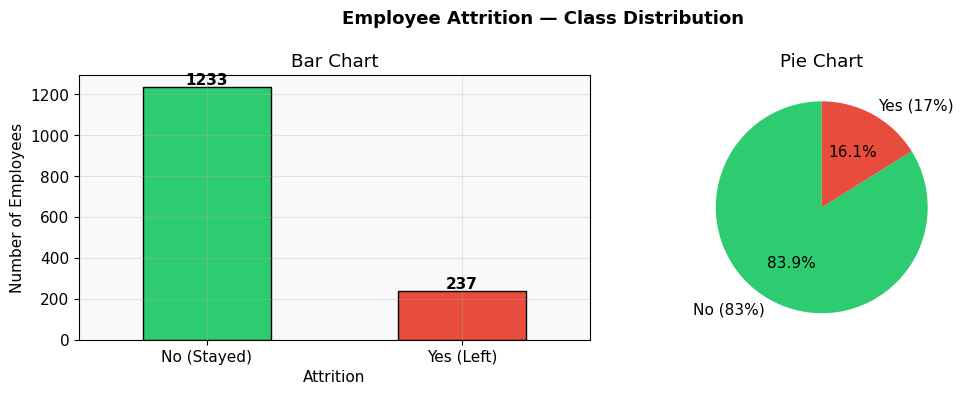

In [6]:
# Target class distribution
attrition_counts = df['Attrition'].value_counts()
total = len(df)

print('Target Variable: Attrition')
print('-' * 35)
for label, count in attrition_counts.items():
    print(f'  {label:5s} : {count:5d}  ({count/total*100:.1f}%)')
print('-' * 35)
print(f'  Imbalance ratio: {attrition_counts["No"]/attrition_counts["Yes"]:.1f} : 1')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Employee Attrition — Class Distribution', fontsize=13, fontweight='bold')

colors = ['#2ecc71', '#e74c3c']
attrition_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Bar Chart')
axes[0].set_xticklabels(['No (Stayed)', 'Yes (Left)'], rotation=0)
axes[0].set_ylabel('Number of Employees')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].pie(attrition_counts, labels=['No (83%)', 'Yes (17%)'],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Pie Chart')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '01_attrition_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Preprocessing

In [7]:
# Step 1: Drop constant columns
constant_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df.drop(columns=constant_cols, inplace=True)

print(f'Dropped constant columns: {constant_cols}')
print(f'Columns remaining: {df.shape[1]}')

Dropped constant columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Columns remaining: 31


In [8]:
# Step 2: Encode all categorical columns with LabelEncoder
le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {categorical_columns}')

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])
    print(f'  Encoded: {col}')

print('\nAll categorical columns encoded successfully.')

Categorical columns to encode: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
  Encoded: Attrition
  Encoded: BusinessTravel
  Encoded: Department
  Encoded: EducationField
  Encoded: Gender
  Encoded: JobRole
  Encoded: MaritalStatus
  Encoded: OverTime

All categorical columns encoded successfully.


In [9]:
# Step 3: Separate features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print(f'Features (X) shape: {X.shape}')
print(f'Target   (y) shape: {y.shape}')

Features (X) shape: (1470, 30)
Target   (y) shape: (1470,)


In [10]:
# Step 4: Train / Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Train/Test Split Summary')
print('-' * 40)
print(f'  Training samples : {X_train.shape[0]}  (80%)')
print(f'  Test samples     : {X_test.shape[0]}   (20%)')
print(f'  Features         : {X_train.shape[1]}')
print('-' * 40)
print(f'  Train — No: {(y_train==0).sum()}  Yes: {(y_train==1).sum()}')
print(f'  Test  — No: {(y_test==0).sum()}   Yes: {(y_test==1).sum()}')

Train/Test Split Summary
----------------------------------------
  Training samples : 1176  (80%)
  Test samples     : 294   (20%)
  Features         : 30
----------------------------------------
  Train — No: 986  Yes: 190
  Test  — No: 247   Yes: 47


## 4. Build & Train Random Forest Model

In [11]:
# Random Forest Classifier
#
#   n_estimators=100     → 100 decision trees
#   class_weight=balanced → compensates for 83/17 imbalance
#   max_features=sqrt    → reduces correlation between trees
#   random_state=42      → reproducible results
#   n_jobs=-1            → use all CPU cores

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest model...')
rf_model.fit(X_train, y_train)
print('Training complete!')
print(f'Number of trees  : {rf_model.n_estimators}')
print(f'Features used    : {rf_model.n_features_in_}')

Training Random Forest model...
Training complete!
Number of trees  : 100
Features used    : 30


## 5. Model Evaluation

In [12]:
# Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(f'Predictions generated for {len(y_pred)} test samples.')

Predictions generated for 294 test samples.


In [13]:
# Compute all evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print('=' * 50)
print('     RANDOM FOREST — FINAL PERFORMANCE METRICS')
print('=' * 50)
print(f'  Accuracy  : {accuracy*100:.2f}%')
print(f'  F1 Score  : {f1*100:.2f}%')
print(f'  Precision : {precision*100:.2f}%')
print(f'  Recall    : {recall*100:.2f}%')
print(f'  ROC-AUC   : {roc_auc*100:.2f}%')
print('=' * 50)

print('\nDetailed Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=['No Attrition (0)', 'Attrition (1)']
))

     RANDOM FOREST — FINAL PERFORMANCE METRICS
  Accuracy  : 83.67%
  F1 Score  : 14.29%
  Precision : 44.44%
  Recall    : 8.51%
  ROC-AUC   : 75.74%

Detailed Classification Report:
                  precision    recall  f1-score   support

No Attrition (0)       0.85      0.98      0.91       247
   Attrition (1)       0.44      0.09      0.14        47

        accuracy                           0.84       294
       macro avg       0.65      0.53      0.53       294
    weighted avg       0.78      0.84      0.79       294



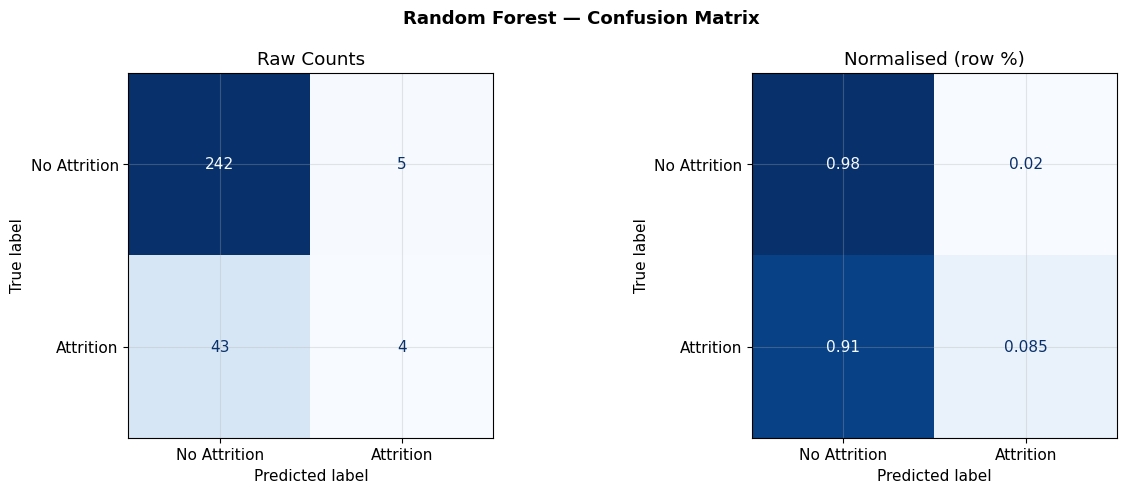

True Negatives  (correctly predicted No) : 242
False Positives (predicted Yes, was No)  : 5
False Negatives (predicted No, was Yes)  : 43  ← missed attrition cases
True Positives  (correctly predicted Yes): 4


In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Attrition', 'Attrition'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Raw Counts')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                               display_labels=['No Attrition', 'Attrition'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Normalised (row %)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '02_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly predicted No) : {tn}')
print(f'False Positives (predicted Yes, was No)  : {fp}')
print(f'False Negatives (predicted No, was Yes)  : {fn}  ← missed attrition cases')
print(f'True Positives  (correctly predicted Yes): {tp}')

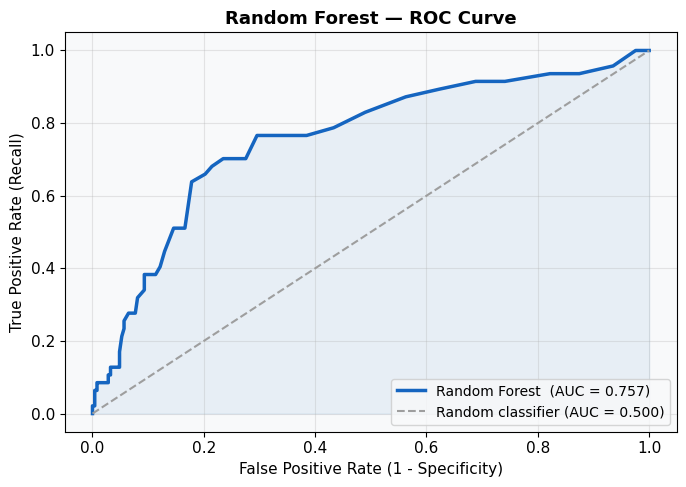

In [15]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#1565C0', lw=2.5,
         label=f'Random Forest  (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#9E9E9E', linestyle='--', lw=1.5,
         label='Random classifier (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.07, color='#1565C0')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Random Forest — ROC Curve', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '03_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance

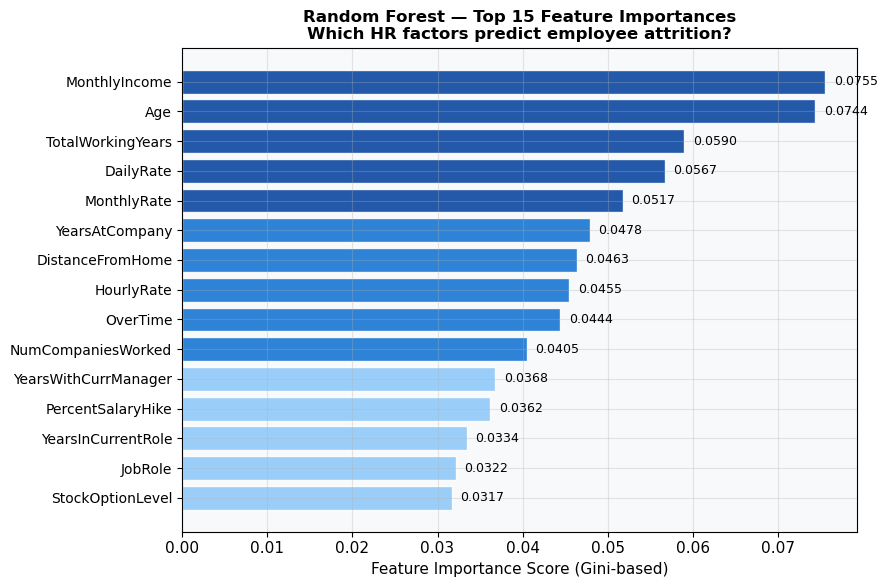

Top 5 most important features for predicting attrition:
  1. MonthlyIncome                 : 0.0755
  2. Age                           : 0.0744
  3. TotalWorkingYears             : 0.0590
  4. DailyRate                     : 0.0567
  5. MonthlyRate                   : 0.0517


In [16]:
# Feature importance based on mean Gini impurity reduction across all trees
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_n = 15
top_features = feature_importance.head(top_n)

colors = ['#0D47A1'] * 5 + ['#1976D2'] * 5 + ['#90CAF9'] * 5

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    range(top_n),
    top_features.values[::-1],
    color=colors[::-1],
    alpha=0.9, edgecolor='white'
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features.index[::-1], fontsize=10)
ax.set_xlabel('Feature Importance Score (Gini-based)')
ax.set_title(
    f'Random Forest — Top {top_n} Feature Importances\n'
    'Which HR factors predict employee attrition?',
    fontsize=12, fontweight='bold'
)

for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, '04_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 most important features for predicting attrition:')
for i, (feat, score) in enumerate(feature_importance.head(5).items(), 1):
    print(f'  {i}. {feat:30s}: {score:.4f}')

## 7. Results Summary

In [17]:
print('=' * 55)
print('       RANDOM FOREST — COMPLETE RESULTS SUMMARY')
print('=' * 55)
print(f'  Algorithm        : Random Forest Classifier')
print(f'  Dataset          : IBM HR Analytics — 1,470 employees')
print(f'  Features used    : {X.shape[1]} (after dropping 4 constant cols)')
print(f'  Train/Test split : 80% / 20% (stratified)')
print(f'  Class weights    : balanced')
print(f'  n_estimators     : 100')
print('-' * 55)
print(f'  Accuracy         : {accuracy*100:.2f}%')
print(f'  F1 Score         : {f1*100:.2f}%')
print(f'  Precision        : {precision*100:.2f}%')
print(f'  Recall           : {recall*100:.2f}%')
print(f'  ROC-AUC          : {roc_auc*100:.2f}%')
print('=' * 55)

       RANDOM FOREST — COMPLETE RESULTS SUMMARY
  Algorithm        : Random Forest Classifier
  Dataset          : IBM HR Analytics — 1,470 employees
  Features used    : 30 (after dropping 4 constant cols)
  Train/Test split : 80% / 20% (stratified)
  Class weights    : balanced
  n_estimators     : 100
-------------------------------------------------------
  Accuracy         : 83.67%
  F1 Score         : 14.29%
  Precision        : 44.44%
  Recall           : 8.51%
  ROC-AUC          : 75.74%


## 8. Export Performance Metrics to CSV

In [18]:
# Export Performance Metrics
import os
import pandas as pd
from datetime import datetime

metrics_dict = {
    'Accuracy (%)'    : round(accuracy * 100, 2),
    'F1 Score (%)'    : round(f1 * 100, 2),
    'Precision (%)'   : round(precision * 100, 2),
    'Recall (%)'      : round(recall * 100, 2),
    'ROC-AUC (%)'     : round(roc_auc * 100, 2)
}

output_file = os.path.join(METRICS_PATH, 'RandomForest_Metrics.csv')
pd.DataFrame([metrics_dict]).to_csv(output_file, index=False)

print('METRICS EXPORTED SUCCESSFULLY')
print(f'Saved to : {output_file}')


METRICS EXPORTED SUCCESSFULLY
Saved to : Performance_Metrics\RandomForest_Metrics.csv
